<a href="https://colab.research.google.com/github/MeLBiN122/AI-ML/blob/main/intern_day5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB()
}

results = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    print(f"{name}: {acc:.4f}")

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])


Logistic Regression: 0.9412
KNN: 0.7647
Decision Tree: 0.7451
SVM: 0.8627
Naive Bayes: 0.7647

Best Model: Logistic Regression
Best Accuracy: 0.9411764705882353


Saving new_img2.webp to new_img2 (2).webp


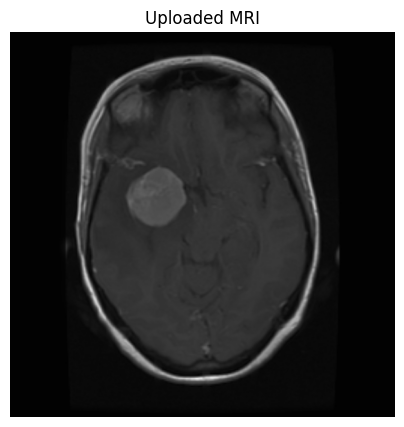


Prediction: No Tumor Detected
Tumor Probability: 0.90%
No Tumor Probability: 99.10%


In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = next(iter(uploaded))

img = cv2.imread(image_path)

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Uploaded MRI")
plt.axis("off")
plt.show()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = cv2.resize(gray, (64,64))

gray = gray.flatten()

gray = gray.reshape(1,-1)

gray = scaler.transform(gray)

prediction = best_model.predict(gray)

prob = best_model.predict_proba(gray)

if prediction[0] == 1:
    result = "Tumor Detected"
else:
    result = "No Tumor Detected"

print("\nPrediction:", result)
print(f"Tumor Probability: {prob[0][1]*100:.2f}%")
print(f"No Tumor Probability: {prob[0][0]*100:.2f}%")